<img src="../Decorative-Elements/Section-03/ADL-S03-Image-01.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../02-Understanding-Rebound/05-Keplers-Law-Representation.ipynb" target="_blank">Previous</a>
  <a href="../03-Solar-System/02-Simulation-of-Earth-and-Moon.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-03/ADL-S03-Image-02.png">

In [1]:
# Solar System Simulations in REBOUND

# A solar system is a gravitationally bound system consisting of a star (like the Sun) 
# and the objects orbiting it, such as planets, moons, asteroids, and comets.

# REBOUND allows us to simulate such systems by numerically integrating the positions 
# and velocities of bodies using different integrators.

# 1. Simulation of Earth and Sun
# - Add the Sun as the central massive body.
# - Add Earth as a particle orbiting the Sun.
# - Choose an integrator (e.g., 'whfast') and timestep.
# - Integrate the system to simulate Earth's orbit around the Sun.

# 2. Simulation of Earth and Moon
# - Add Earth as the central body.
# - Add Moon as a particle orbiting Earth.
# - Use a suitable integrator and timestep.
# - Integrate to simulate the Moon's orbit around Earth.

# 3. Simulation of Sun, Earth, and Moon
# - Add Sun, Earth, and Moon with correct masses and initial orbital parameters.
# - The system simulates Earth's orbit around Sun and Moon's orbit around Earth simultaneously.
# - Use integrators like 'ias15' for higher accuracy.

# 4. Simulation of all planets in the Solar System
# - Add the Sun and all planets (Mercury to Neptune) with their masses and initial orbital elements.
# - Integrate the system over desired time to see planetary orbits.
# - Symplectic integrators like 'whfast' are efficient for long-term stability.

# 5. Simulation of each planet and their moons
# - For each planet, add the planet and its major moons.
# - Simulate individual planet-moon systems or nested with Sun for full orbital dynamics.
# - Allows studying moon dynamics, tidal interactions, and resonances.

# Notes:
# - REBOUND handles N-body dynamics using integrators.
# - Choosing the right integrator depends on system size, required accuracy, 
# and presence of close encounters.
# - Particle positions and velocities can be visualized using OrbitPlot or 3D plots.

<img src="../Decorative-Elements/Section-03/ADL-S03-Image-03.png">

In [2]:
import rebound
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
import plotly.graph_objects as go

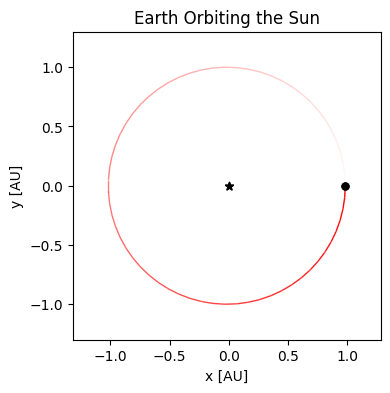

In [3]:
# Create simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')  # Astronomical Units, years, solar mass

# Add Sun (central body)
sim.add(m=1.0)  # mass in solar masses

# Add Earth
sim.add(m=3e-6, a=1.0, e=0.0167)  # Earth mass ~3e-6 Msun, a=1 AU, small eccentricity

# Move simulation to center-of-mass frame
sim.move_to_com()

# Optional: integrate for 1 year (not strictly needed for orbit plot)
sim.integrate(1.0)

# Plot orbit using Rebound's OrbitPlot
fig = rebound.OrbitPlot(sim, unitlabel="[AU]", color=True, figsize=(4,4))
plt.title("Earth Orbiting the Sun")
plt.show()

In [4]:
# Initialize simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')
sim.add(m=1.0)                     # Sun
sim.add(m=3e-6, a=1.0, e=0.0167)   # Earth
sim.move_to_com()

def plot_earth_epoch(delta_days=0):

    # Plot Earth's position based on number of days since epoch (Jan 1, 2000) plus delta_days.
    
    # Parameters:
    # delta_days (float): Number of days to move forward (>0) or backward (<0) from today.
    # Default is 0 (current position).

    # Define epoch
    epoch = datetime(2000, 1, 1)
    today = datetime.now()
    
    # Compute target date with delta_days
    target_date = today + timedelta(days=delta_days)
    
    # Compute total days since epoch
    total_days_since_epoch = (target_date - epoch).days + (target_date - epoch).seconds/86400
    
    # Convert days to years for simulation
    years_since_epoch = total_days_since_epoch / 365.25
    
    # Integrate simulation to target time
    sim_temp = sim.copy()
    sim_temp.integrate(years_since_epoch)
    
    # Plot orbit
    fig = rebound.OrbitPlot(sim_temp, unitlabel="[AU]", color=True, figsize=(4,4))
    
    # Highlight Earth's position
    earth = sim_temp.particles[1]
    plt.scatter(earth.x, earth.y, color='red', s=80,
                label=f"Earth on {target_date.strftime('%Y-%m-%d')}", zorder=5)
    
    plt.title(f"Earth Orbiting Sun on {target_date.strftime('%Y-%m-%d')}")
    plt.legend()
    plt.show()

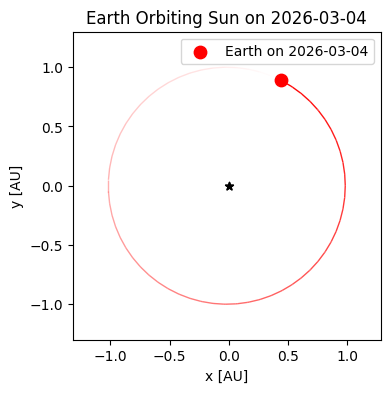

In [5]:
# Example usage
plot_earth_epoch()       # Today

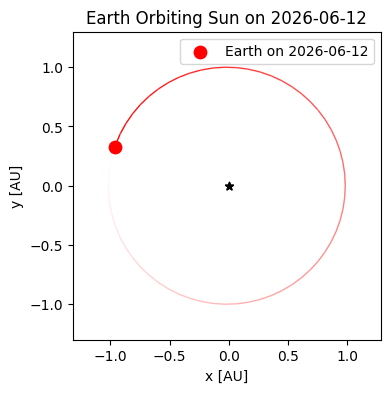

In [6]:
plot_earth_epoch(100)     # 100 days in future

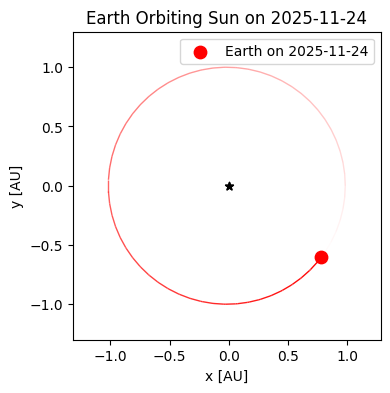

In [7]:
plot_earth_epoch(-100)    # 100 days in past

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


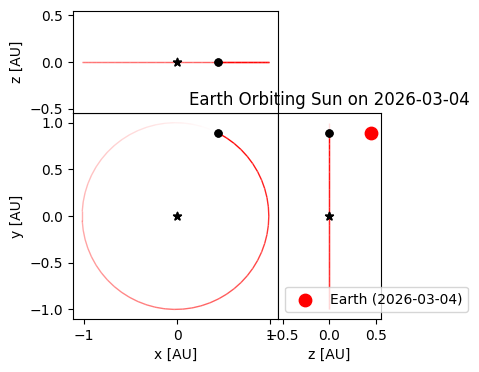

In [8]:
# Compute current time since epoch (Jan 1, 2000)
epoch = datetime(2000, 1, 1)
today = datetime.now()
days_since_epoch = (today - epoch).days + (today - epoch).seconds / 86400
years_since_epoch = days_since_epoch / 365.25

# Integrate simulation to today
sim.integrate(years_since_epoch)

# Plot using OrbitPlotSet
rebound.OrbitPlotSet(sim, unitlabel='[AU]', color=True, figsize=(4,4))

# Highlight Earth
earth = sim.particles[1]
plt.scatter(earth.x, earth.y, color='red', s=80, label=f"Earth ({today.strftime('%Y-%m-%d')})", zorder=5)

plt.title(f"Earth Orbiting Sun on {today.strftime('%Y-%m-%d')}")
plt.legend()
plt.show()

In [9]:
def plot_earth_orbit(delta_days=0):

    # Plot Earth's orbit with Sun, highlighting Earth's position.
    
    # Parameters:
    # delta_days (float): Days to move forward (>0) or backward (<0) from today.
    # Default is 0 (current date).

    # Compute target date
    today = datetime.now()
    target_date = today + timedelta(days=delta_days)
    
    # Compute total days since epoch
    epoch = datetime(2000, 1, 1)
    total_days_since_epoch = (target_date - epoch).days + (target_date - epoch).seconds / 86400
    
    # Convert days to years for simulation
    years_since_epoch = total_days_since_epoch / 365.25
    
    # Integrate simulation
    sim_temp = sim.copy()
    sim_temp.integrate(years_since_epoch)
    
    # Plot orbit
    rebound.OrbitPlotSet(sim_temp, unitlabel='[AU]', color=True, figsize=(4,4))
    
    # Highlight Earth
    earth = sim_temp.particles[1]
    plt.scatter(earth.x, earth.y, color='red', s=80,
                label=f"Earth ({target_date.strftime('%Y-%m-%d')})", zorder=5)
    
    plt.title(f"Earth Orbiting Sun on {target_date.strftime('%Y-%m-%d')}")
    plt.legend()
    plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


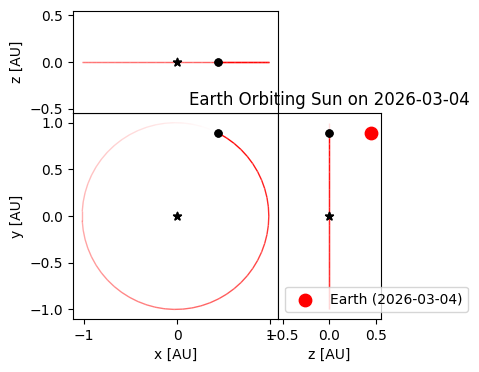

In [10]:
# Examples
plot_earth_orbit()        # Today

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


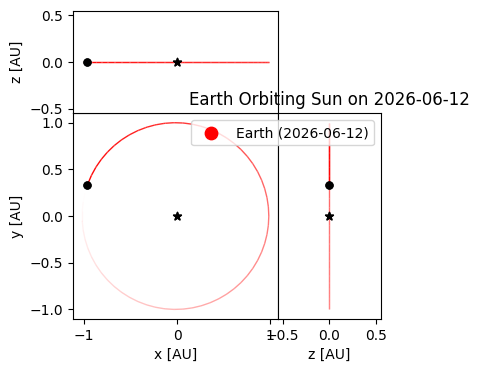

In [11]:
plot_earth_orbit(100)      # 100 days in the future

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


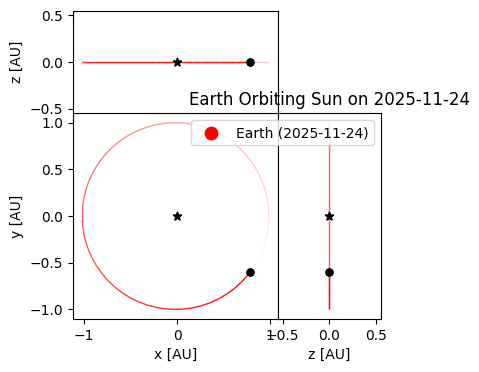

In [12]:
plot_earth_orbit(-100)     # 100 days in the past

In [13]:
# Orbital parameters (circular orbit)
a = 1.0               # AU
frames_count = 12      # 12 months
theta = np.linspace(0, 2*np.pi, 1000)  # full orbit for trace

# Orbit trace
x_orbit = a * np.cos(theta)
y_orbit = a * np.sin(theta)
z_orbit = np.zeros_like(theta)

# Earth positions for each month
theta_frames = np.linspace(0, 2*np.pi, frames_count, endpoint=False)
x_frames = a * np.cos(theta_frames)
y_frames = a * np.sin(theta_frames)
z_frames = np.zeros_like(theta_frames)

# Corresponding month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create figure with initial positions
fig = go.Figure(
    data=[
        go.Scatter3d(x=[0], y=[0], z=[0],
                     mode='markers', marker=dict(size=10, color='yellow'),
                     name='Sun'),
        go.Scatter3d(x=x_orbit, y=y_orbit, z=z_orbit,
                     mode='lines', line=dict(color='black', dash='dash'),
                     name='Orbit'),
        go.Scatter3d(x=[x_frames[0]], y=[y_frames[0]], z=[z_frames[0]],
                     mode='markers', marker=dict(size=6, color='blue'),
                     name='Earth')
    ],
    layout=go.Layout(
        title="3D Earth-Sun Orbit with Slider (12 months)",
        scene=dict(xaxis_title='X (AU)', yaxis_title='Y (AU)', zaxis_title='Z (AU)'),
        updatemenus=[dict(type="buttons",
                          buttons=[dict(label="Play",
                                        method="animate",
                                        args=[None, dict(frame=dict(duration=500, redraw=True),
                                                         fromcurrent=True, mode='immediate')])])],
        sliders=[dict(
            steps=[dict(method='animate',
                        args=[[f'Month {k+1}'],
                              dict(mode='immediate', frame=dict(duration=500, redraw=True), transition=dict(duration=0))],
                        label=month_labels[k]) for k in range(frames_count)],
            active=0,
            currentvalue=dict(prefix="Month: "),
            pad=dict(t=50)
        )]
    ),
    frames=[go.Frame(
        data=[
            go.Scatter3d(x=[0], y=[0], z=[0],  # Sun always visible
                         mode='markers', marker=dict(size=10, color='yellow'),
                         name='Sun'),
            go.Scatter3d(x=x_orbit, y=y_orbit, z=z_orbit,
                         mode='lines', line=dict(color='black', dash='dash'),
                         name='Orbit'),
            go.Scatter3d(x=[x_frames[k]], y=[y_frames[k]], z=[z_frames[k]],
                         mode='markers', marker=dict(size=6, color='blue'),
                         name='Earth')
        ],
        name=f'Month {k+1}'
    ) for k in range(frames_count)]
)

fig.show()

# Output is not visible in github webpage, refer to Folder/Output-Plotly

<p style="display: flex; justify-content: space-between;">
  <a href="../02-Understanding-Rebound/05-Keplers-Law-Representation.ipynb" target="_blank">Previous</a>
  <a href="../03-Solar-System/02-Simulation-of-Earth-and-Moon.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-03-01.gif">